<a href="https://colab.research.google.com/github/selinalee09/Python-Works/blob/main/RDkit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
!pip install rdkit

In [56]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors
from rdkit.Chem.SaltRemover import SaltRemover
from rdkit.Chem.MolStandardize import rdMolStandardize

import pandas as pd

In [57]:
data = {"Drug": ["Lapatinib","Gefitinib","Tamoxifen","Palbociclib","Osimertinib","Sotorasib","Anastrozole","Crizotinib"],
        "Cancer": ["Breast","Lung","Breast","Breast","Lung","Lung","Breast","Lung"],
        "SMILES": ["CS(=O)(=O)CCNCC1=CC=C(O1)C2=CC3=C(C=C2)N=CN=C3NC4=CC(=C(C=C4)OCC5=CC(=CC=C5)F)Cl","COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OCCCN4CCOCC4", "CC/C(=C(\C1=CC=CC=C1)/C2=CC=C(C=C2)OCCN(C)C)/C3=CC=CC=C3", "CC1=C(C(=O)N(C2=NC(=NC=C12)NC3=NC=C(C=C3)N4CCNCC4)C5CCCC5)C(=O)C", "CN1C=C(C2=CC=CC=C21)C3=NC(=NC=C3)NC4=C(C=C(C(=C4)NC(=O)C=C)N(C)CCN(C)C)OC", "C[C@H]1CN(CCN1C2=NC(=O)N(C3=NC(=C(C=C32)F)C4=C(C=CC=C4F)O)C5=C(C=CN=C5C(C)C)C)C(=O)C=C", "CC(C)(C#N)C1=CC(=CC(=C1)CN2C=NC=N2)C(C)(C)C#N", "C[C@H](C1=C(C=CC(=C1Cl)F)Cl)OC2=C(N=CC(=C2)C3=CN(N=C3)C4CCNCC4)N"]}
df = pd.DataFrame(data)
df

<>:3: SyntaxWarning: invalid escape sequence '\C'
<>:3: SyntaxWarning: invalid escape sequence '\C'
/tmp/ipykernel_2612/363324491.py:3: SyntaxWarning: invalid escape sequence '\C'
  "SMILES": ["CS(=O)(=O)CCNCC1=CC=C(O1)C2=CC3=C(C=C2)N=CN=C3NC4=CC(=C(C=C4)OCC5=CC(=CC=C5)F)Cl","COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OCCCN4CCOCC4", "CC/C(=C(\C1=CC=CC=C1)/C2=CC=C(C=C2)OCCN(C)C)/C3=CC=CC=C3", "CC1=C(C(=O)N(C2=NC(=NC=C12)NC3=NC=C(C=C3)N4CCNCC4)C5CCCC5)C(=O)C", "CN1C=C(C2=CC=CC=C21)C3=NC(=NC=C3)NC4=C(C=C(C(=C4)NC(=O)C=C)N(C)CCN(C)C)OC", "C[C@H]1CN(CCN1C2=NC(=O)N(C3=NC(=C(C=C32)F)C4=C(C=CC=C4F)O)C5=C(C=CN=C5C(C)C)C)C(=O)C=C", "CC(C)(C#N)C1=CC(=CC(=C1)CN2C=NC=N2)C(C)(C)C#N", "C[C@H](C1=C(C=CC(=C1Cl)F)Cl)OC2=C(N=CC(=C2)C3=CN(N=C3)C4CCNCC4)N"]}


,Drug,Cancer,SMILES
0,Lapatinib,Breast,CS(=O)(=O)CCNCC1=CC=C(O1)C2=CC3=C(C=C2)N=CN=C3...
1,Gefitinib,Lung,COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OC...
2,Tamoxifen,Breast,CC/C(=C(\C1=CC=CC=C1)/C2=CC=C(C=C2)OCCN(C)C)/C...
3,Palbociclib,Breast,CC1=C(C(=O)N(C2=NC(=NC=C12)NC3=NC=C(C=C3)N4CCN...
4,Osimertinib,Lung,CN1C=C(C2=CC=CC=C21)C3=NC(=NC=C3)NC4=C(C=C(C(=...
5,Sotorasib,Lung,C[C@H]1CN(CCN1C2=NC(=O)N(C3=NC(=C(C=C32)F)C4=C...
6,Anastrozole,Breast,CC(C)(C#N)C1=CC(=CC(=C1)CN2C=NC=N2)C(C)(C)C#N
7,Crizotinib,Lung,C[C@H](C1=C(C=CC(=C1Cl)F)Cl)OC2=C(N=CC(=C2)C3=...


In [58]:
df["Molecule"] = df["SMILES"].apply(
    lambda x: Chem.MolFromSmiles(x) if x else None)
remover = SaltRemover()
uncharger = rdMolStandardize.Uncharger()

def clean_molecule(mol):
    if mol is None:
        return None
    mol = remover.StripMol(mol)
    mol = uncharger.uncharge(mol)
    return mol

df["Molecule_Clean"] = df["Molecule"].apply(clean_molecule)
df["Molecular Weight"] = df["Molecule_Clean"].apply(
    lambda m: Descriptors.MolWt(m) if m else None)
df["LogP"] = df["Molecule_Clean"].apply(
    lambda m: Crippen.MolLogP(m) if m else None)
df["TPSA"] = df["Molecule_Clean"].apply(
    lambda m: rdMolDescriptors.CalcTPSA(m, includeSandP=True) if m else None)
df["HBD"] = df["Molecule_Clean"].apply(
    lambda m: Lipinski.NumHDonors(m) if m else None)
df["HBA"] = df["Molecule_Clean"].apply(
    lambda m: Lipinski.NumHAcceptors(m) if m else None)
df["Rotatable Bonds"] = df["Molecule_Clean"].apply(
    lambda m: Lipinski.NumRotatableBonds(m) if m else None)
df["Rings"] = df["Molecule_Clean"].apply(
    lambda m: Lipinski.RingCount(m) if m else None)
df["Aromatic Rings"] = df["Molecule_Clean"].apply(
    lambda m: Lipinski.NumAromaticRings(m) if m else None)
df["Heavy Atoms"] = df["Molecule_Clean"].apply(
    lambda m: Lipinski.HeavyAtomCount(m) if m else None)
df["Fraction sp3"] = df["Molecule_Clean"].apply(
    lambda m: rdMolDescriptors.CalcFractionCSP3(m) if m else None)
columns = ["Drug", "Cancer", "Molecular Weight","TPSA", "HBD","HBA", "Rotatable Bonds","Rings","Aromatic Rings","Heavy Atoms", "Fraction sp3","LogP"]
df[columns]

,Drug,Cancer,Molecular Weight,TPSA,HBD,HBA,Rotatable Bonds,Rings,Aromatic Rings,Heavy Atoms,Fraction sp3,LogP
0,Lapatinib,Breast,581.069,114.73,2,8,11,5,5,40,0.172414,6.13910
1,Gefitinib,Lung,446.910,68.74,1,7,8,4,3,31,0.363636,4.27560
2,Tamoxifen,Breast,371.524,12.47,0,2,8,3,3,28,0.230769,5.99610
3,Palbociclib,Breast,447.543,105.04,2,8,5,5,3,33,0.458333,2.96582
4,Osimertinib,Lung,499.619,87.55,2,7,10,4,4,37,0.250000,4.50980
5,Sotorasib,Lung,560.605,104.45,1,7,5,5,4,41,0.300000,4.48142
6,Anastrozole,Breast,293.374,78.29,0,4,4,2,2,22,0.411765,2.92876
7,Crizotinib,Lung,450.345,77.99,2,5,5,4,3,30,0.333333,5.03770


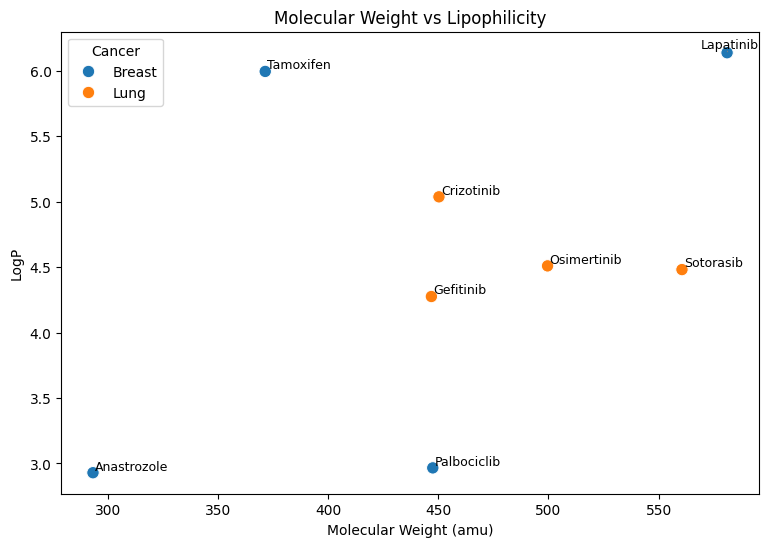

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
!pip install adjustText
from adjustText import adjust_text

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Molecular Weight", y="LogP", hue="Cancer", s=80)
texts = []
for _, row in df.iterrows():
    texts.append(
        plt.text(
            row["Molecular Weight"],
            row["LogP"],
            row["Drug"],
            fontsize=9,))
adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray", lw=0.6, alpha=0.7))
plt.title("Molecular Weight vs Lipophilicity")
plt.xlabel("Molecular Weight (amu)")
plt.show()

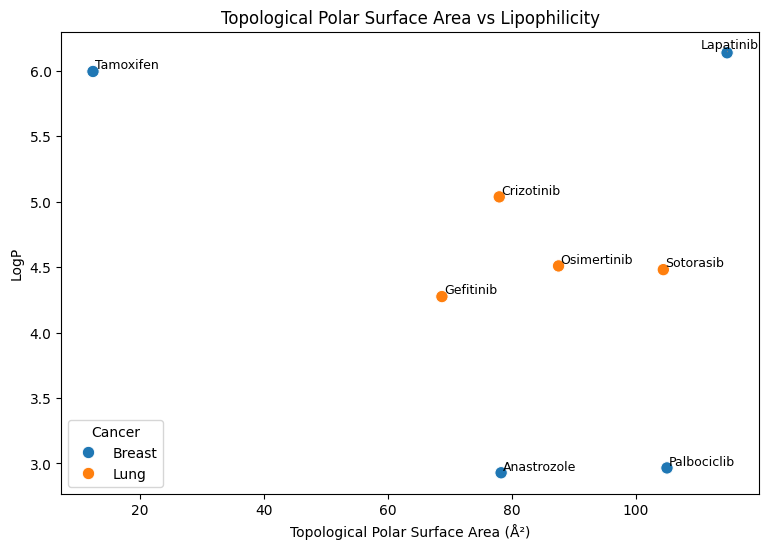

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
!pip install adjustText
from adjustText import adjust_text

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="TPSA", y="LogP", hue="Cancer", s=80)
texts = []
for _, row in df.iterrows():
    texts.append(
        plt.text(
            row["TPSA"],
            row["LogP"],
            row["Drug"],
            fontsize=9,))
adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray", lw=0.6, alpha=0.7))
plt.title("Topological Polar Surface Area vs Lipophilicity")
plt.xlabel("Topological Polar Surface Area (Å²)")
plt.show()

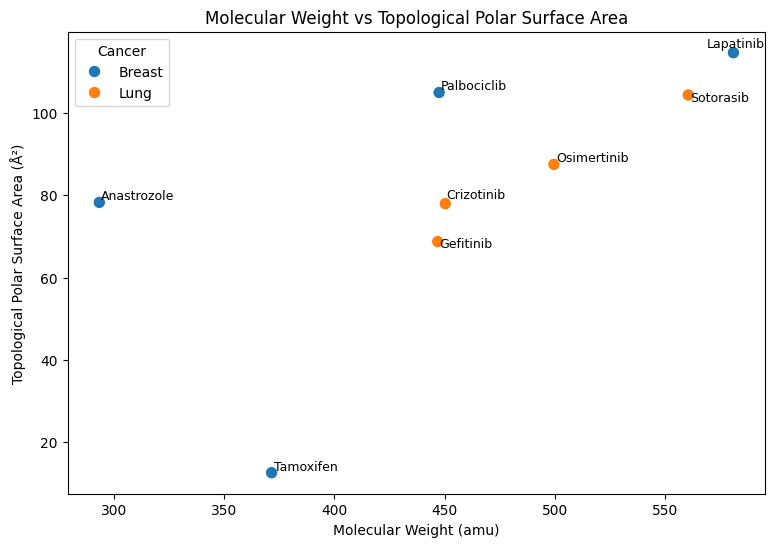

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
!pip install adjustText
from adjustText import adjust_text

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Molecular Weight", y="TPSA", hue="Cancer", s=80)
texts = []
for _, row in df.iterrows():
    texts.append(
        plt.text(
            row["Molecular Weight"],
            row["TPSA"],
            row["Drug"],
            fontsize=9,))
adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray", lw=0.6, alpha=0.7))
plt.title("Molecular Weight vs Topological Polar Surface Area")
plt.xlabel("Molecular Weight (amu)")
plt.ylabel("Topological Polar Surface Area (Å²)")
plt.show()

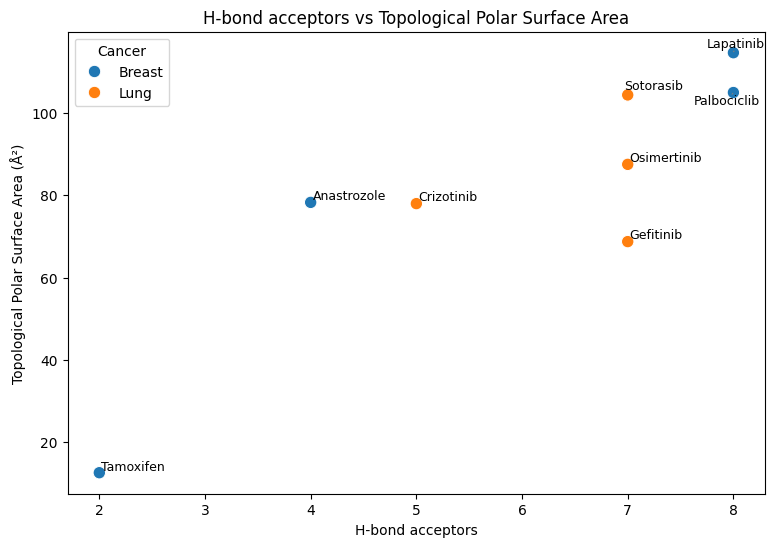

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
!pip install adjustText
from adjustText import adjust_text

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="HBA", y="TPSA", hue="Cancer", s=80)
texts = []
for _, row in df.iterrows():
    texts.append(
        plt.text(
            row["HBA"],
            row["TPSA"],
            row["Drug"],
            fontsize=9,))
adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray", lw=0.6, alpha=0.7))
plt.title("H-bond acceptors vs Topological Polar Surface Area")
plt.xlabel("H-bond acceptors")
plt.ylabel("Topological Polar Surface Area (Å²)")
plt.show()

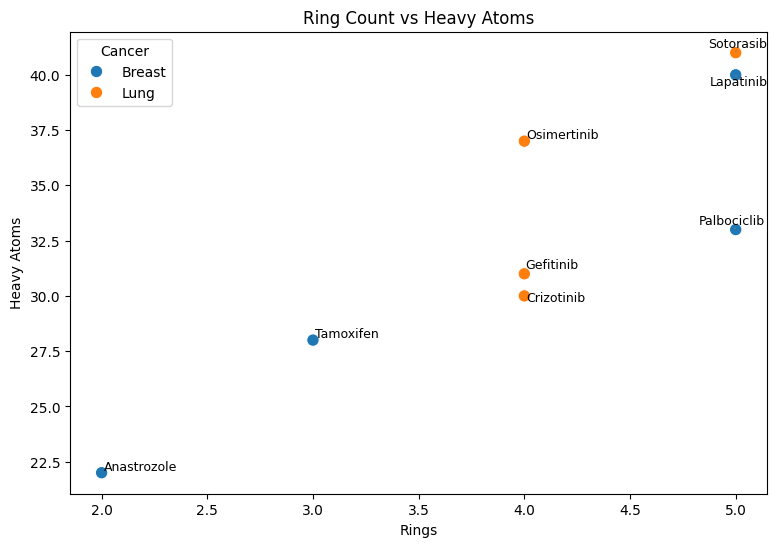

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
!pip install adjustText
from adjustText import adjust_text

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Rings", y="Heavy Atoms", hue="Cancer", s=80)
texts = []
for _, row in df.iterrows():
    texts.append(
        plt.text(
            row["Rings"],
            row["Heavy Atoms"],
            row["Drug"],
            fontsize=9,))
adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray", lw=0.6, alpha=0.7))
plt.title("Ring Count vs Heavy Atoms")
plt.xlabel("Rings")
plt.ylabel("Heavy Atoms")
plt.show()

In [65]:
from rdkit.Chem import rdFingerprintGenerator

generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
df["Fingerprint"] = df["Molecule"].apply(generator.GetFingerprint)

from rdkit import DataStructs

def similarity(fp1, fp2):
    return DataStructs.TanimotoSimilarity(fp1, fp2)

lap = df.loc[df["Drug"] == "Lapatinib", "Fingerprint"].iloc[0]
gef = df.loc[df["Drug"] == "Gefitinib", "Fingerprint"].iloc[0]

similarity(lap, gef)

0.31683168316831684

In [66]:
tam = df.loc[df["Drug"] == "Tamoxifen", "Fingerprint"].iloc[0]
pal = df.loc[df["Drug"] == "Palbociclib", "Fingerprint"].iloc[0]

similarity(tam, pal)

0.07777777777777778

In [67]:
osi = df.loc[df["Drug"] == "Osimertinib", "Fingerprint"].iloc[0]
sot = df.loc[df["Drug"] == "Sotorasib", "Fingerprint"].iloc[0]

similarity(osi, sot)

0.1693548387096774

In [68]:
ana = df.loc[df["Drug"] == "Anastrozole", "Fingerprint"].iloc[0]
cri = df.loc[df["Drug"] == "Crizotinib", "Fingerprint"].iloc[0]

similarity(ana, cri)

0.09302325581395349

In [69]:
drugs = df["Drug"].tolist()
similarity_matrix = pd.DataFrame(
    index=drugs,
    columns=drugs)

for i in range(len(drugs)):
    for j in range(len(drugs)):
        similarity_matrix.iloc[i, j] = DataStructs.TanimotoSimilarity(
            df.iloc[i]["Fingerprint"],
            df.iloc[j]["Fingerprint"])

similarity_matrix

,Lapatinib,Gefitinib,Tamoxifen,Palbociclib,Osimertinib,Sotorasib,Anastrozole,Crizotinib
Lapatinib,1.0,0.316832,0.08,0.08871,0.125984,0.104478,0.080808,0.146552
Gefitinib,0.316832,1.0,0.104651,0.109091,0.171171,0.115702,0.105882,0.176471
Tamoxifen,0.08,0.104651,1.0,0.077778,0.166667,0.067961,0.061538,0.067416
Palbociclib,0.08871,0.109091,0.077778,1.0,0.147826,0.17094,0.054945,0.150943
Osimertinib,0.125984,0.171171,0.166667,0.147826,1.0,0.169355,0.094737,0.101695
Sotorasib,0.104478,0.115702,0.067961,0.17094,0.169355,1.0,0.079208,0.125
Anastrozole,0.080808,0.105882,0.061538,0.054945,0.094737,0.079208,1.0,0.093023
Crizotinib,0.146552,0.176471,0.067416,0.150943,0.101695,0.125,0.093023,1.0


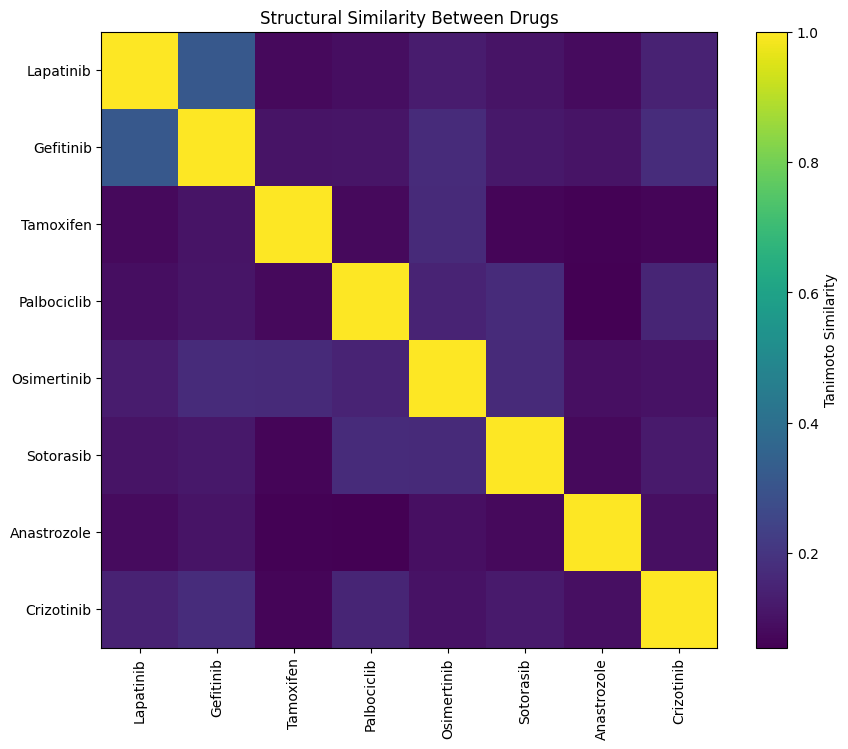

In [70]:
plt.figure(figsize=(10,8))

plt.imshow(
    similarity_matrix.astype(float),
    interpolation="nearest"
)

plt.xticks(range(len(drugs)), drugs, rotation=90)
plt.yticks(range(len(drugs)), drugs)

plt.colorbar(label="Tanimoto Similarity")

plt.title("Structural Similarity Between Drugs")

plt.show()